## 1. Charger et prétraiter l'ensemble de données MNIST

In [2]:
%pip install tensorflow matplotlib

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow import keras

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.3 MB 2.2 MB/s eta 0:00:04
   --- ------------------------------------ 0.8/9.3 MB 2.2 MB/s eta 0:00:04
   ----- ---------------------------------- 1.3/9.3 MB 1.6 MB/s eta 0:00:06
   ------ --------------------------------- 1.6/9.3 MB 1.6 MB/s eta 0:00:05
   -------- ------------------------------- 2.1/9.3 MB 1.7 MB/s eta 0:00:05
   ----------- ---------------------------- 2.6/9.3 MB 1.8 MB/s eta 0:00:04
   ------------- -------------------------- 3.1/9.3 MB 1.9 MB/s eta 0:00:04
   --------------- ------------------------ 3.7/9.3 MB 2.0 MB/s eta 0:00:03
   ----------------- ---------------------- 4.2/9.3 MB 2.0 MB/s eta 0:00:03
   -------------------- ------------------- 4.7/


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Charger le jeu de données MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normaliser les valeurs des pixels de l'image pour qu'elles soient comprises entre 0 et 1
x_train = x_train / 255.0
x_test = x_test / 255.0

# Convertir les étiquettes au format encodé one-hot
y_train_one_hot = keras.utils.to_categorical(y_train, num_classes=10)
y_test_one_hot = keras.utils.to_categorical(y_test, num_classes=10)

print(f"Shape of x_train: {x_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of x_test: {x_test.shape}")
print(f"Shape of y_test: {y_test.shape}")
print(f"Shape of y_train_one_hot: {y_train_one_hot.shape}")
print(f"Shape of y_test_one_hot: {y_test_one_hot.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Shape of x_train: (60000, 28, 28)
Shape of y_train: (60000,)
Shape of x_test: (10000, 28, 28)
Shape of y_test: (10000,)
Shape of y_train_one_hot: (60000, 10)
Shape of y_test_one_hot: (10000, 10)


### Afficher des exemples d'images avec leurs étiquettes correspondantes

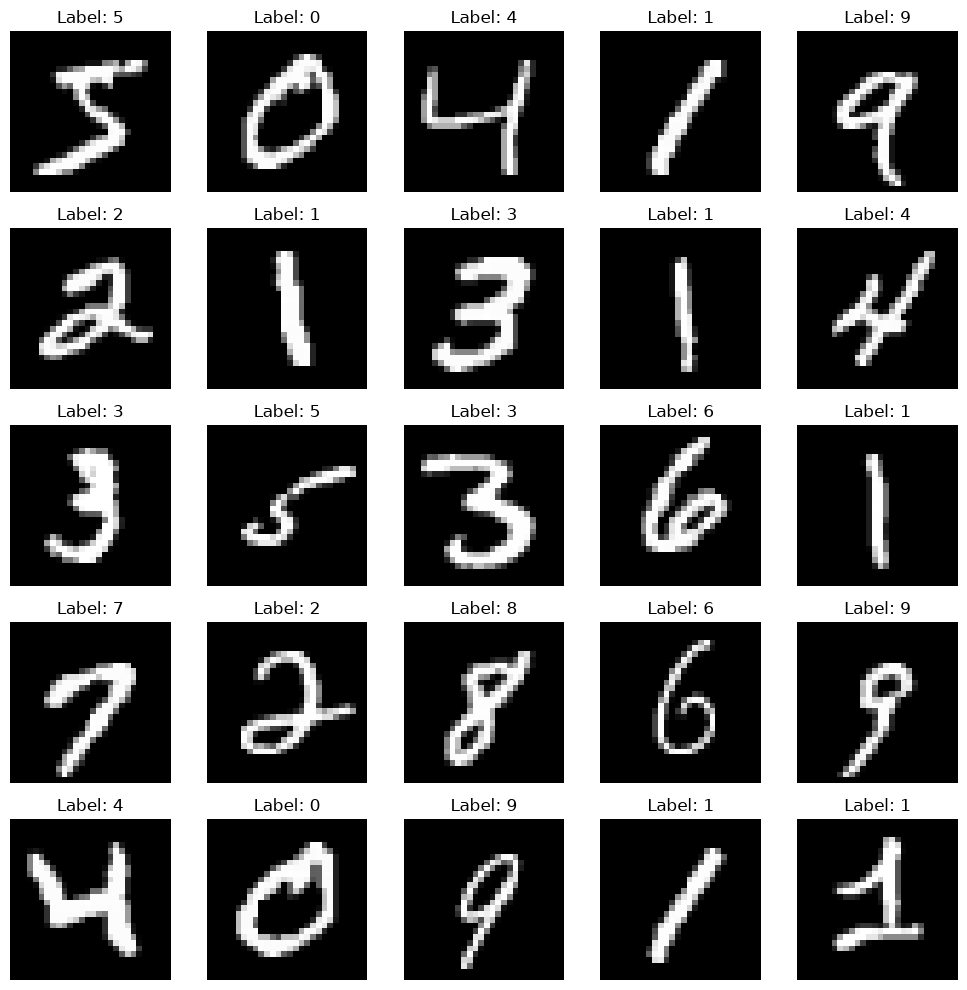

In [4]:
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## 2. Construire un réseau neuronal entièrement connecté

In [5]:
# Définir un modèle séquentiel
model = keras.Sequential([
    # Aplatir les images d'entrée 28x28 en un seul vecteur
    keras.layers.Flatten(input_shape=(28, 28)),
    # Ajouter deux couches cachées avec activation ReLU
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    # Ajouter une couche de sortie avec activation Softmax pour la classification multiclasse
    keras.layers.Dense(10, activation='softmax')
])

# Compilez le modèle
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\meles\Documents\TTA_DI_BootCamp_Gilles-Chris_MAKE\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Entraîner le réseau neuronal

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9214 - loss: 0.2668 - val_accuracy: 0.9602 - val_loss: 0.1348
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9661 - loss: 0.1124 - val_accuracy: 0.9677 - val_loss: 0.1133
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9757 - loss: 0.0767 - val_accuracy: 0.9671 - val_loss: 0.1072
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9814 - loss: 0.0578 - val_accuracy: 0.9718 - val_loss: 0.1017
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9853 - loss: 0.0460 - val_accuracy: 0.9693 - val_loss: 0.1163
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9886 - loss: 0.0357 - val_accuracy: 0.9723 - val_loss: 0.1082
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9893 - loss: 0.0311 - val_accuracy: 0.9733 - val_loss: 0.0995
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9921 - loss: 0.0240 - 

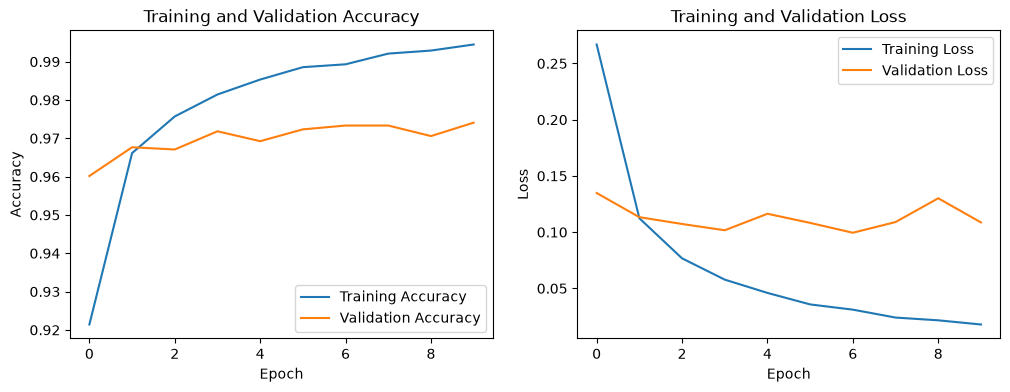

In [6]:
# Entraîner le modèle
history = model.fit(
    x_train, y_train_one_hot,
    epochs=10,
    validation_split=0.2 # Utiliser un ensemble de validation pour suivre les performances pendant l'entraînement
)

# Observez les tendances en matière de perte et de précision au fil des époques
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## 4. Évaluer les performances du modèle

In [7]:
# Calculer la précision sur l'ensemble de données de test
loss, accuracy = model.evaluate(x_test, y_test_one_hot)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9756 - loss: 0.0991
Test Loss: 0.0991
Test Accuracy: 0.9756



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ------ --------------------------------- 1.3/8.2 MB 9.6 MB/s eta 0:00:01
   ----------------- ---------------------- 3.7/8.2 MB 10.9 MB/s eta 0:00:01
   ------------------------------ --------- 6.3/8.2 MB 11.0 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 10.4 MB/s eta 0:00:00
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ------ --------------------------------- 1.6/9.8 MB 27.9 MB/s eta 0:00:01
   --------------- ------------------------ 3.7/9.8 MB 14.6 MB/s eta 0:00:01
   ------------------------ --

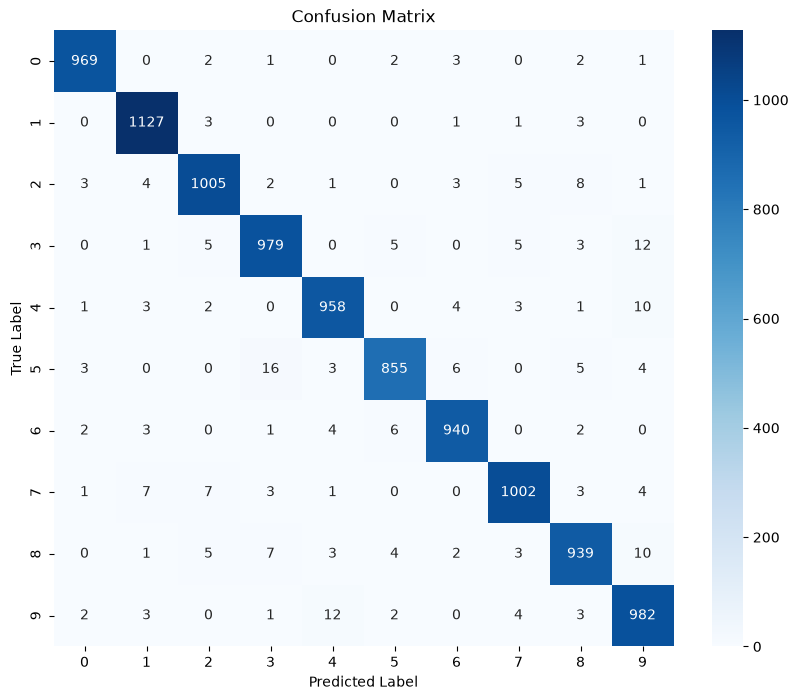

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


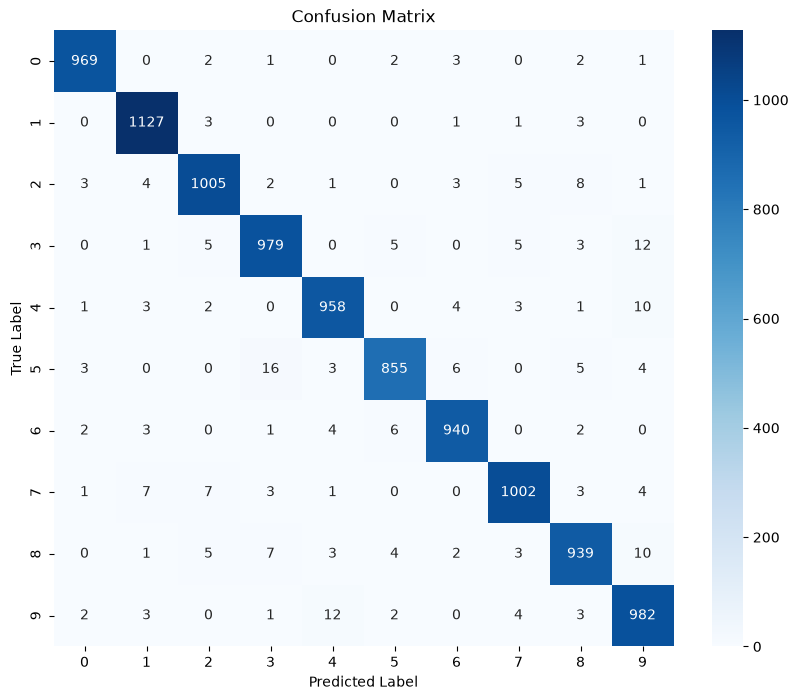

In [9]:
%pip install seaborn scikit-learn

from sklearn.metrics import confusion_matrix
import seaborn as sns

# Obtenir les prédictions du modèle sur l'ensemble de test
y_pred_one_hot = model.predict(x_test)
y_pred = np.argmax(y_pred_one_hot, axis=1)

# Afficher une matrice de confusion
conf_mat = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()
import seaborn as sns

# Obtenir les prédictions du modèle sur l'ensemble de test
y_pred_one_hot = model.predict(x_test)
y_pred = np.argmax(y_pred_one_hot, axis=1)

# Afficher une matrice de confusion
conf_mat = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### Identifier les chiffres avec lesquels le modèle a le plus de difficultés

Chiffres avec lesquels le modèle a le plus de difficultés (par nombre d'erreurs):
Chiffre 5: 37 erreurs
Chiffre 8: 35 erreurs
Chiffre 3: 31 erreurs
Chiffre 9: 27 erreurs
Chiffre 2: 27 erreurs
Chiffre 7: 26 erreurs
Chiffre 4: 24 erreurs
Chiffre 6: 18 erreurs
Chiffre 0: 11 erreurs
Chiffre 1: 8 erreurs

Exemples de chiffres mal classés:


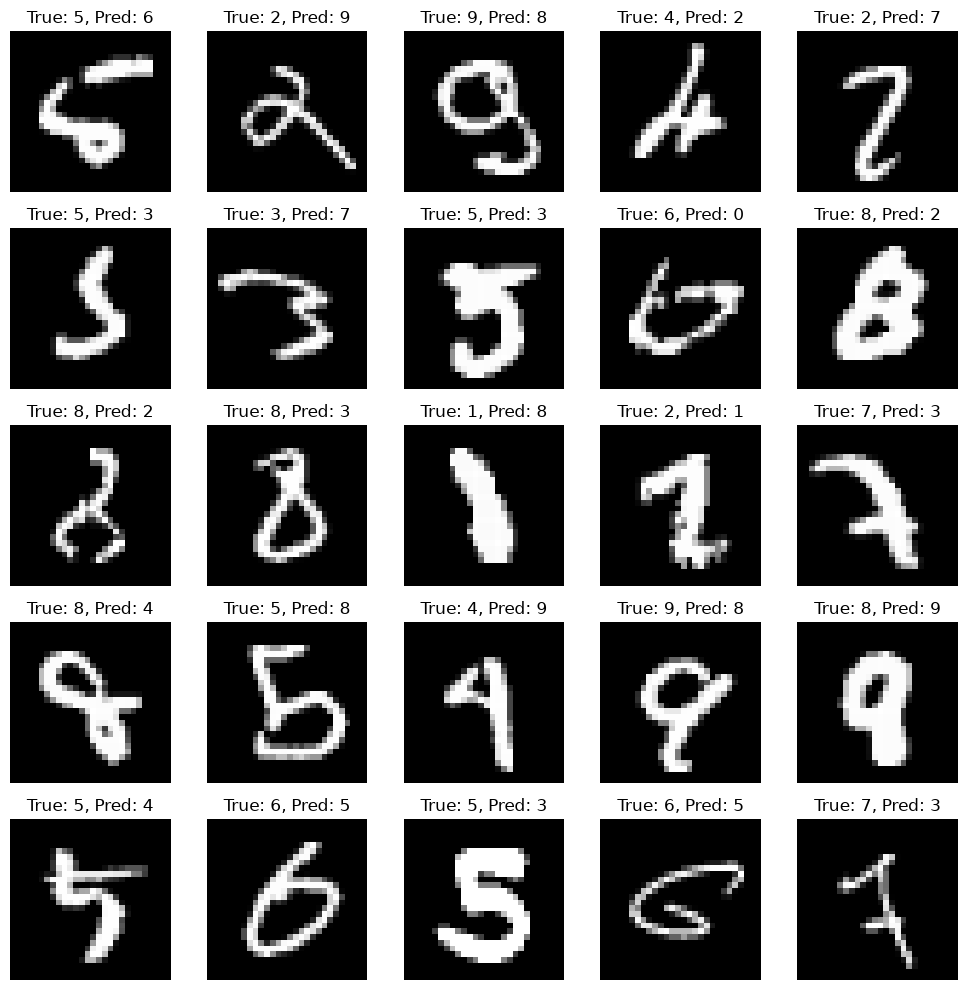

In [10]:
# Calculer le nombre d'erreurs pour chaque chiffre
errors_per_digit = np.zeros(10)
for i in range(10):
    errors_per_digit[i] = np.sum((y_test == i) & (y_test != y_pred))

# Afficher les chiffres avec le plus d'erreurs
most_difficult_digits = np.argsort(errors_per_digit)[::-1]

print("Chiffres avec lesquels le modèle a le plus de difficultés (par nombre d'erreurs):")
for digit in most_difficult_digits:
    print(f"Chiffre {digit}: {int(errors_per_digit[digit])} erreurs")

# Afficher quelques exemples de chiffres mal classés
print("\nExemples de chiffres mal classés:")
plt.figure(figsize=(10, 10))
misclassified_indices = np.where(y_test != y_pred)[0]
for i, bad_index in enumerate(misclassified_indices[:25]): # Afficher jusqu'à 25 exemples
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_test[bad_index], cmap='gray')
    plt.title(f"True: {y_test[bad_index]}, Pred: {y_pred[bad_index]}")
    plt.axis('off')
plt.tight_layout()
plt.show()